# Compost Bin Data Analysis

Our project explores **323 days** of sensor data from two compost bins.  
The data was collected from **May 2025 to March 2026** in a cold climate (Lapland, Finland).

Each bin has sensors at three levels:
- **Lower** (bottom of the bin)
- **Middle** (center of the bin)
- **Upper** (top of the bin)

Main factors to look:
1. **Temperature** — how hot the compost gets
2. **Moisture** — how wet the compost is
3. **Heating** — how much electricity is used to keep the bins warm in winter
4. **Outside vs Compost bin temperature** — comparing outdoor cold vs compost warmth

---

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('../data/combined_compost_measurements.csv')

df['Day'] = pd.to_datetime(df['Day'])

df.head()

,Day,Compost 1-Inside-Heating - kWh,Compost 1-Inside-Heating - w,Compost 1-Lower-Moisture,Compost 1-Lower-Temperature,Compost 1-Middle-Moisture,Compost 1-Middle-Temperature,Compost 1-Upper-Moisture,Compost 1-Upper-Temperature,Compost 2-Inside-Heating - kWh,...,Growing-Sensor 07-Moisture,Growing-Sensor 08-Moisture,Growing-Sensor 09-Moisture,Growing-Sensor 10-Moisture,Growing-Sensor 11-Moisture,Growing-Sensor 12-Moisture,Outside-Outside-Moisture,Outside-Outside-Temperature,Shed-Shed-Moisture,Shed-Shed-Temperature
0,2025-05-06,0.0,0.0,17.9,0.7,16.5,2.4,0.0,2.7,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,43.7,2.8,44.3,2.3
1,2025-05-07,0.0,0.0,18.6,1.4,19.6,3.2,0.0,3.7,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,44.4,2.8,44.7,2.4
2,2025-05-08,0.0,0.0,19.2,2.6,19.7,4.6,0.0,5.4,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,46.5,4.5,47.5,3.8
3,2025-05-09,0.0,0.0,19.6,5.0,20.0,6.9,0.0,7.4,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,47.5,5.9,49.1,4.9
4,2025-05-10,0.0,0.0,19.7,8.6,20.2,9.8,0.0,9.6,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,44.2,8.0,45.8,6.9


In [5]:
# Since the data is not useable after 2025-09-16,
# I will filter the data and focus on this period for analysis.
df = df[(df['Day'] <= '2025-09-16')]

In [6]:
df.shape

(134, 43)

In [7]:
df.isna().sum()

Day                                 0
Compost 1-Inside-Heating - kWh      0
Compost 1-Inside-Heating - w        0
Compost 1-Lower-Moisture            0
Compost 1-Lower-Temperature         0
Compost 1-Middle-Moisture           0
Compost 1-Middle-Temperature        0
Compost 1-Upper-Moisture            0
Compost 1-Upper-Temperature         0
Compost 2-Inside-Heating - kWh      0
Compost 2-Inside-Heating - w        0
Compost 2-Lower-Moisture            0
Compost 2-Lower-Temperature         0
Compost 2-Middle-Moisture           0
Compost 2-Middle-Temperature        0
Compost 2-Upper-Moisture            0
Compost 2-Upper-Temperature         0
Growing-18E0-Moisture             134
Growing-18E0-Temperature          134
Growing-4B21-Moisture             134
Growing-4B21-Temperature          134
Growing-5D20-Moisture             134
Growing-5D20-Temperature          134
Growing-E43B-Moisture             134
Growing-E43B-Temperature          134
Growing-R9A5E-Moisture            134
Growing-R9A5

## Section 1: Temperature

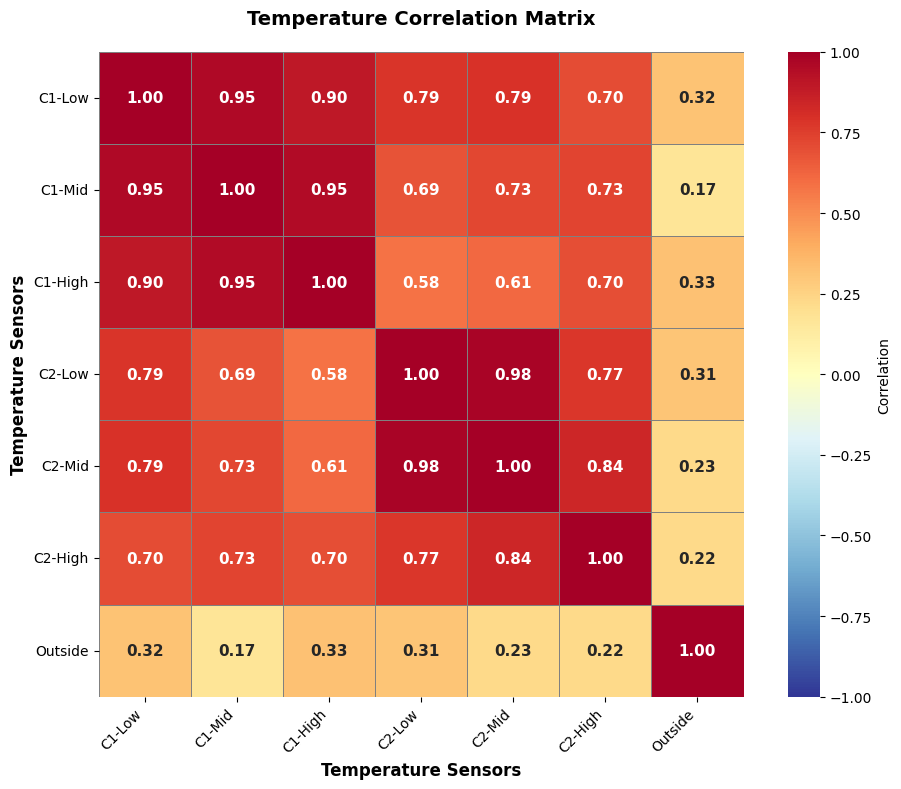

In [8]:
temp_cols = [
    'Compost 1-Lower-Temperature', 'Compost 1-Middle-Temperature', 'Compost 1-Upper-Temperature',
    'Compost 2-Lower-Temperature', 'Compost 2-Middle-Temperature', 'Compost 2-Upper-Temperature',
    'Outside-Outside-Temperature'
]

# Create shorter labels for readability
short_labels = ['C1-Low', 'C1-Mid', 'C1-High', 'C2-Low', 'C2-Mid', 'C2-High', 'Outside']

corr_matrix = df[temp_cols].corr()
corr_matrix.index = short_labels
corr_matrix.columns = short_labels

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', square=True, 
            cbar_kws={'label': 'Correlation'}, linewidths=0.5, linecolor='gray',
            vmin=-1, vmax=1, annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Temperature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Temperature Sensors', fontsize=12, fontweight='bold')
plt.ylabel('Temperature Sensors', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### **Observation:** All compost temperature layers correlate strongly with each other. The outside temperature has a weaker correlation with the compost layers. Which means the compost bins are sealed properly
___

# Bin 1 - Temperature

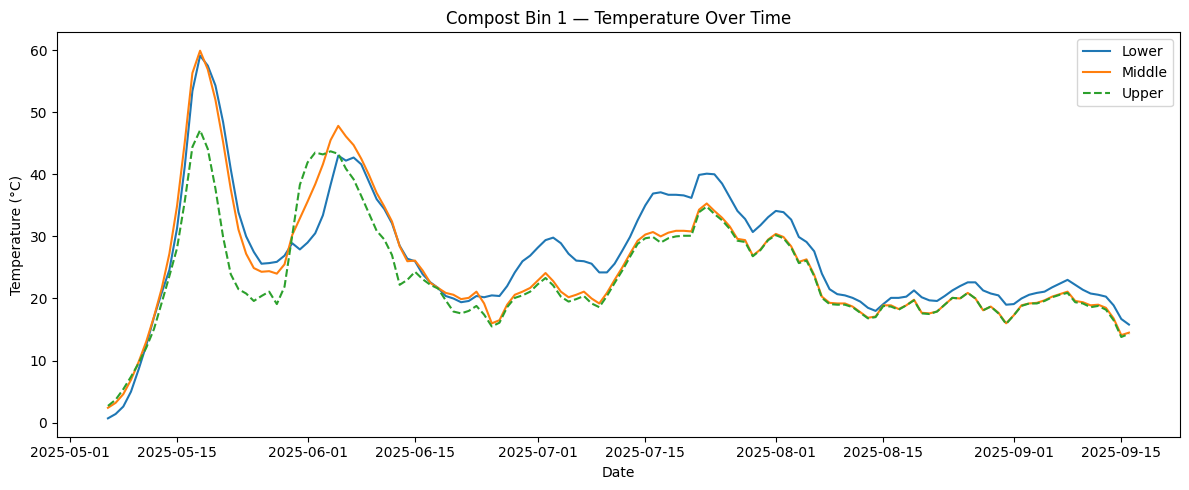

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(df['Day'], df['Compost 1-Lower-Temperature'],  label='Lower')
plt.plot(df['Day'], df['Compost 1-Middle-Temperature'], label='Middle')
plt.plot(df['Day'], df['Compost 1-Upper-Temperature'],  label='Upper', linestyle='--')
plt.title('Compost Bin 1 — Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

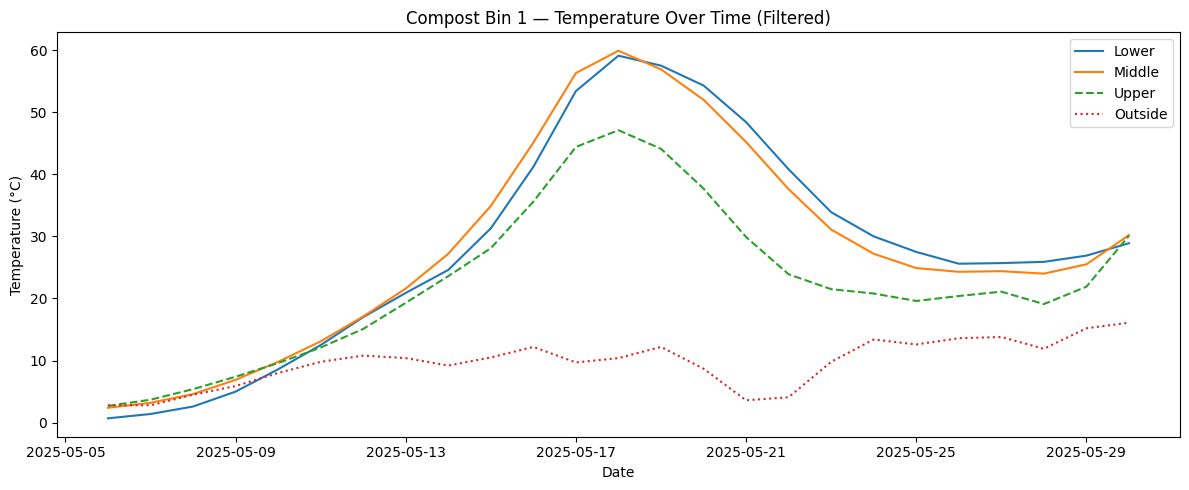

In [10]:
df_filtered = df[(df['Day'] <= '2025-05-30')]

plt.figure(figsize=(12, 5))
plt.plot(df_filtered['Day'], df_filtered['Compost 1-Lower-Temperature'],  label='Lower')
plt.plot(df_filtered['Day'], df_filtered['Compost 1-Middle-Temperature'], label='Middle')
plt.plot(df_filtered['Day'], df_filtered['Compost 1-Upper-Temperature'],  label='Upper', linestyle='--')
plt.plot(df_filtered['Day'], df_filtered['Outside-Outside-Temperature'], label='Outside', linestyle=':')
plt.title('Compost Bin 1 — Temperature Over Time (Filtered)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

# Temperature Analysis: Composting Bin (May 6 – May 30, 2025)


<h2 style="color: red; font-weight: bold">What the data shows:</h2>

- Temperature **rise steadily** and peaked at **60°C within two weeks**
- Following the peak, it gradually **dropped to 25°C within one week**
- The **lower and middle layers** had similar temperature readings
- The **upper layer** had lower temperatures
  - which is expected as the majority of microbial decomposition activity is concentrated in the lower sections of the bin
- Correlation analysis confirmed **no significant relationship between external ambient temperature and internal bin temperature** during this period which means that heat generation was primarily driven by biological activity rather than environmental conditions

---

<h2 style="color: #0bf207 ; font-weight: bold">Research:</h2> 

### Interpretation - The Thermophilic Composting Phenomenon:

The observed temperature spike is consistent with a well documented biological phenomenon known as the **thermophilic stage of composting**. This occurs when microorganisms decompose organic material and release metabolic heat as a by product. The temperature range of **32°C to 60°C** observed in this data is characteristic of rapid decomposition activity. This typically triggered shortly after fresh material is introduced to the bin.

---

## The Three Phases of Composting

<h3 style="color: #f7c41ce7; font-weight: bold">Phase 1 - Mesophilic Stage(Warm-Up)</h3>

- Temperature range: **20–45°C**
- Lasts **a few days**

Initial decomposition is carried out by mesophilic microorganisms. which break down readily available and soluble organic compounds such as simple sugars and starches. Their metabolic activity generates heat to raise the pile temperature to approximately **40–45°C**. From this point conditions become unfavourable for mesophiles and the next phase begins. This early warming trend is visible in the chart data from the first days of the observation period.

<h3 style="color: #e46c40; font-weight: bold">Phase 2 — Thermophilic Stage(Hot Phase)</h3>

- Temperature range: **40–70°C**
- **Duration:** Several weeks to a few months
- The pile can shrink by **40–60%** as material breaks down.

As temperatures exceed 40°C, Thermophilic bacteria (members of the genus *Bacillus*) take over the decomposition process. During this phase:

- Complex organic compounds including **proteins, fats, cellulose, and hemicellulose** are broken down
- The physical volume of the pile can decrease by **40–60%** due to material breakdown and moisture loss
- A natural **pasteurisation effect** occurs This eliminates harmful pathogens such as *Salmonella* and *E. coli*
- Temperatures above **65°C** become counterproductive because even thermophilic bacteria begin to die off at excessive heat levels

The peak temperature of **60°C recorded within two weeks** in this dataset. This is consistent with the expected thermophilic temperature range.

<h3 style="color: #4be66f; font-weight: bold">Phase 3 — Cooling and Maturation (Curing Stage)</h3>

- **Temperature range:** Declining toward ambient (~25°C)  
- **Duration:** Several weeks to months

As the supply of high energy organic compounds becomes less, microbial activity slows and temperatures decline.During this phase:

- Bacterial populations decrease significantly as available food sources decreses.
- **Fungi** become the decomposers. breaking down more resistant materials such as woody particles
- Macroorganisms such as **earthworms** recolonise the cooler regions of the pile. They contributing to further breakdown.
- The compost stabilises and matures into a biologically stable end product

The decline to **25°C** observed in the dataset aligns with the expected onset of this curing phase.

---

<h2 style="color: #1350d4 ; font-weight: bold">Summary:</h2> 

| **Phase** | **Temperature** | **What Happens** |
|---|---|---|
| Mesophilic | 20–45°C | Bacteria warm up the pile |
| Thermophilic | 40–70°C | Peak heat, pathogens destroyed |
| Curing | Drops to ~25°C | Fungi and worms finish the job |

---

### Sources
- https://agriculture.institute/organic-production-system/three-stages-of-composting/
- https://compostsegria.com/ca/en/fases-del-compostaje/
- https://www.chelseagreen.com/blog/the-phases-of-composting/